In [1]:
import sys
from pathlib import Path

# Put the repo root on sys.path so `util.*` and `saes.*` resolve regardless of
# whether the kernel was launched from `Interp_LM4/` or `saes/`.
REPO_ROOT = Path.cwd() if (Path.cwd() / "saes").is_dir() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from pathlib import Path

MODEL_DIR  = Path("../model/BD_llama_6heads_1epoch_4layers")
DATA_DIR   = Path("../data/BD_llama_inital")
REMAP_PATH = DATA_DIR / "old_to_new.json"
TOKENS_PATH = DATA_DIR / "bios_postreduce.bin"

SAE_PATH = "/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_runs/sweep-n66crzzw/mult16_l05_lr3e-05_ep50_n10000/final"

### Load Model, Data, and Tokenizer

In [3]:
from util.condensed_tokenizer import CondensedTokenizer
from util.bio_sampler import BioSampler

tokenizer = CondensedTokenizer.from_remap_path(REMAP_PATH)
sampler   = BioSampler(DATA_DIR / "people.json", fields=("birthday",), seed=0)

print(f"vocab_size = {tokenizer.vocab_size}, eos_token_id = {tokenizer.eos_token_id}")
print(f"{len(sampler.people):,} people, {sampler.n_templates} templates/person\n")

# Specific person + specific template
text = sampler.render(sampler.people[0], exposure_idx=0)
print("render(people[0], 0) →", repr(text))
print("encode →", tokenizer.encode(text)[:15], "...\n")

# Random bio
draw = sampler.sample()
print(f"sample() → person id={draw['person']['id']}, template={draw['exposure_idx']}")
print("text →", repr(draw["text"]))

/Users/efmac/Code/Project Code/CRL-Interp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


vocab_size = 1836, eos_token_id = 1835
50,000 people, 46 templates/person

render(people[0], 0) → ' Gabriella Ella Rigby was born on February 18, 1816.'
encode → [870, 83, 882, 663, 5, 1273, 267, 80, 536, 52, 487, 237, 1, 237, 256] ...

sample() → person id=50494, template=26
text → ' Marco Jackson Rowland arrived in this world on December 24, 1717, a day to be remembered.'


In [4]:
import torch
from transformers import LlamaForCausalLM
from transformer_lens import HookedTransformer, HookedTransformerConfig
from transformer_lens.loading_from_pretrained import convert_llama_weights


def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = pick_device()
dtype = torch.float32

hf_model = LlamaForCausalLM.from_pretrained(MODEL_DIR, torch_dtype=dtype)
hf_model.eval()
assert hf_model.config.vocab_size == tokenizer.vocab_size, (
    f"checkpoint vocab {hf_model.config.vocab_size} != remap vocab "
    f"{tokenizer.vocab_size} — wrong old_to_new.json for this model."
)

# Build the TL config from the HF config so dims match our custom
# 4-layer / hidden=384 / vocab=1836 model (from_pretrained would have used
# the Llama-2-7b template config and tried to read layer 4 of a 4-layer model).
hf_cfg = hf_model.config
tl_cfg = HookedTransformerConfig(
    n_layers = hf_cfg.num_hidden_layers,
    d_model = hf_cfg.hidden_size,
    d_head = hf_cfg.hidden_size // hf_cfg.num_attention_heads,
    n_heads = hf_cfg.num_attention_heads,
    d_mlp= hf_cfg.intermediate_size,
    d_vocab=hf_cfg.vocab_size,
    n_ctx=hf_cfg.max_position_embeddings,
    act_fn="silu",
    normalization_type="RMS",
    gated_mlp=True,
    positional_embedding_type="rotary",
    rotary_base=int(getattr(hf_cfg, "rope_theta", 10000.0)),
    rotary_dim=hf_cfg.hidden_size // hf_cfg.num_attention_heads,
    final_rms=True,
    tie_word_embeddings=hf_cfg.tie_word_embeddings,
    initializer_range=hf_cfg.initializer_range,
    n_key_value_heads=hf_cfg.num_key_value_heads,
    device=device,
)

# Pre-tokenize everything you feed the model; don't attach the tokenizer.
# TL only calls into the tokenizer for `model(str)` / `to_tokens` / `to_string`,
# none of which we use — we always pass token ids directly.
state_dict = convert_llama_weights(hf_model, tl_cfg)
model = HookedTransformer(tl_cfg)
model.load_state_dict(state_dict, strict=False)
model.to(device)
model.eval()
print(f"Loaded on {device}: n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}, "
      f"n_heads={model.cfg.n_heads}, d_vocab={model.cfg.d_vocab}")

`torch_dtype` is deprecated! Use `dtype` instead!


Moving model to device:  mps
Loaded on mps: n_layers=4, d_model=384, n_heads=6, d_vocab=1836


In [5]:
def show_tokens(ids, tokenizer, addOne=False):
    """Print each token with its position and decoded text (with repr so
    leading spaces / newlines stay visible).

    addOne=True shifts the displayed index by 1, so positions match what
    the model sees after a BOS/EOS is prepended to `ids` downstream.
    """
    if hasattr(ids, "tolist"):
        ids = ids.tolist()
    if ids and isinstance(ids[0], list):
        ids = ids[0]   # unwrap [1, N] batch

    offset = 1 if addOne else 0
    id_w = max(len(str(t)) for t in ids)
    idx_w = len(str(len(ids) - 1 + offset))
    print(f"{'idx':>{idx_w}} | {'id':>{id_w}} | text")
    print("-" * (idx_w + id_w + 12))
    for i, t in enumerate(ids):
        print(f"{i + offset:>{idx_w}} | {t:>{id_w}} | {tokenizer.decode([t])!r}")


### Exploring SAE 

#### Setup: load the SAE

The SAE checkpoint is loaded once and reused by every subsequent cell.

In [6]:
from saes.evalSAE import load_sae

sae = load_sae(SAE_PATH, device)
HOOK = "blocks.1.hook_mlp_out"
print(f"d_sae = {sae.cfg.d_sae}, hook = {HOOK}")

d_sae = 6144, hook = blocks.1.hook_mlp_out


/Users/efmac/Code/Project Code/CRL-Interp/.venv/lib/python3.13/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


#### Overview — feature activity histograms

Loads `feature_stats.pt` written by `computeInference.py`. Plots:
- **Activation density** per feature (fraction of tokens where the feature fires).
  The big spike at 0 is dead features.
- **Max activation** per feature.

If the file isn't there yet, run `computeInference.py` on the HPC and
`scp inference/` over.

stats:  sae_inference/mult16_l05_lr3e-05_ep50_n10000/feature_stats.pt  exists: True
d_sae = 6144,  n_tokens = 6,400,000,  dead = 1487


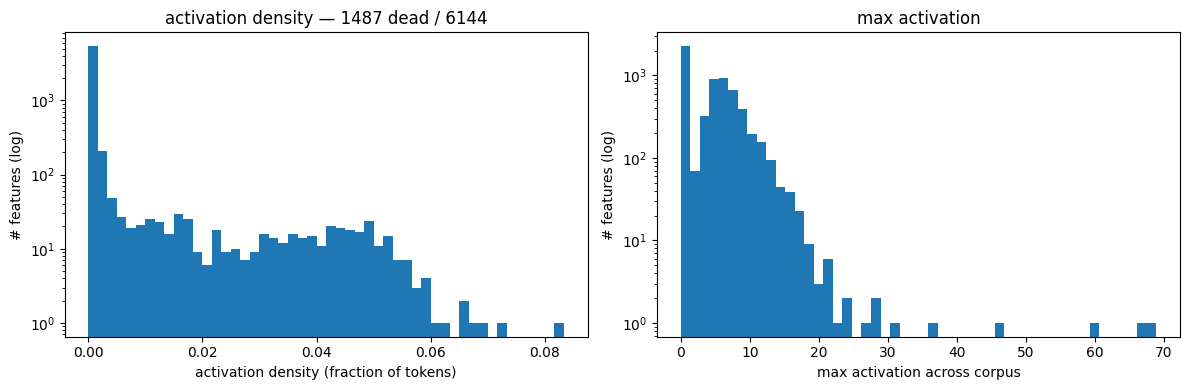

In [7]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

sae_name = Path(SAE_PATH).parent.name
STATS_PATH = Path("sae_inference") / sae_name / "feature_stats.pt"
print("stats: ", STATS_PATH, " exists:", STATS_PATH.exists())

if STATS_PATH.exists():
    stats = torch.load(STATS_PATH, weights_only=False)
    n_dead = int((stats["activation_count"] == 0).sum())
    print(f"d_sae = {sae.cfg.d_sae},  n_tokens = {stats['n_tokens']:,},  dead = {n_dead}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    density = stats["activation_count"].float() / stats["n_tokens"]
    axes[0].hist(density.numpy(), bins=50, log=True)
    axes[0].set_xlabel("activation density (fraction of tokens)")
    axes[0].set_ylabel("# features (log)")
    axes[0].set_title(f"activation density — {n_dead} dead / {sae.cfg.d_sae}")

    axes[1].hist(stats["max_activation"].numpy(), bins=50, log=True)
    axes[1].set_xlabel("max activation across corpus")
    axes[1].set_ylabel("# features (log)")
    axes[1].set_title("max activation")
    plt.tight_layout()
    plt.show()
else:
    print()
    print("⚠ feature_stats.pt missing. Re-run computeInference.py on the HPC, then:")
    print(f"   scp -r friedmae@bridges2:Interp_LM4/inference ./")

#### Activations per latent

Bar plot of how many tokens each feature fires on, indexed by latent.
Tall bars are densely-firing features; bars at zero are dead. Same data
that drives the activation-density histogram above, plotted along the
latent axis instead of binned.

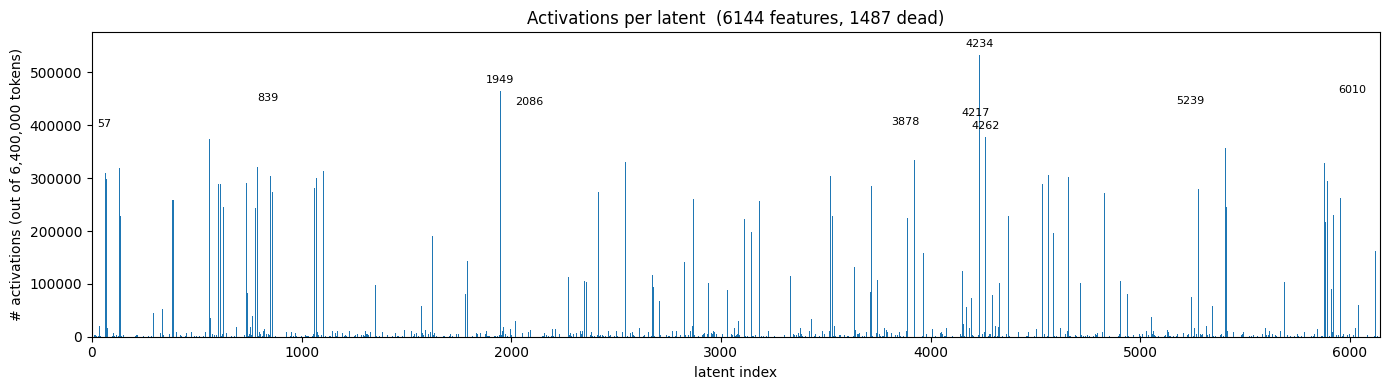


Top 10 latents by activation count:
rank  latent       count   density
   1    4234     533,303    8.333%
   2    1949     465,430    7.272%
   3    6010     447,436    6.991%
   4     839     431,955    6.749%
   5    5239     426,382    6.662%
   6    2086     424,291    6.630%
   7    4217     404,272    6.317%
   8    3878     386,864    6.045%
   9      57     381,841    5.966%
  10    4262     378,085    5.908%


In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

TOP_N = 10  # label the N most-active latents

sae_name = Path(SAE_PATH).parent.name
STATS_PATH = Path("sae_inference") / sae_name / "feature_stats.pt"

if STATS_PATH.exists():
    stats = torch.load(STATS_PATH, weights_only=False)
    counts = stats["activation_count"].numpy()
    n_total = stats["n_tokens"]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(counts)), counts, width=1.0, linewidth=0)
    ax.set_xlabel("latent index")
    ax.set_ylabel(f"# activations (out of {n_total:,} tokens)")
    ax.set_title(f"Activations per latent  ({sae.cfg.d_sae} features, {int((counts == 0).sum())} dead)")
    ax.set_xlim(0, len(counts))

    top_idx = np.argsort(counts)[-TOP_N:][::-1]
    y_offset = counts.max() * 0.01
    for idx in top_idx:
        ax.annotate(
            str(idx),
            xy=(idx, counts[idx]),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8,
        )
    # Headroom so labels aren't clipped
    ax.set_ylim(0, counts.max() * 1.08)

    plt.tight_layout()
    plt.show()

    print(f"\nTop {TOP_N} latents by activation count:")
    print(f"{'rank':>4}  {'latent':>6}  {'count':>10}  {'density':>8}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"{rank:>4}  {idx:>6}  {counts[idx]:>10,}  {counts[idx]/n_total:>8.3%}")
else:
    print("⚠ feature_stats.pt missing. Re-run computeInference.py on the HPC, then:")
    print("   scp -r friedmae@bridges2:Interp_LM4/inference ./")


#### Option A — View precomputed dashboard&nbsp;&nbsp; ← RECOMMENDED

Run `computeInference.py` on the HPC, then download:

```bash
scp -r friedmae@bridges2:Interp_LM4/inference ./
```

Change `FEATURE_IDX` below to inspect a different feature. Each per-feature
HTML is ~500 KB, small enough to embed inline. To see a list of all
rendered features, open `index.html` in your browser (printed below).

In [19]:
import webbrowser
from pathlib import Path
from IPython.display import display, FileLink

FEATURE_IDX = 6010  # change me — use Pick-a-feature cell below to find interesting ones

sae_name = Path(SAE_PATH).parent.name
DASHBOARD_DIR = Path("sae_inference") / sae_name
feature_html = DASHBOARD_DIR / f"dashboard_feature_{FEATURE_IDX}.html"
index_html = DASHBOARD_DIR / "index.html"

print("feature file:", feature_html)
print("exists:      ", feature_html.exists())

if feature_html.exists():
    abs_path = feature_html.resolve()
    print("\nopening in browser:", abs_path)
    webbrowser.open(abs_path.as_uri())

    # Clickable fallbacks in case the auto-open is blocked.
    print("\nclick to open:")
    display(FileLink(str(abs_path)))
    if index_html.exists():
        print("full index:")
        display(FileLink(str(index_html.resolve())))
else:
    if not DASHBOARD_DIR.exists():
        print("\n⚠ No dashboard dir. Run computeInference.py on the HPC first, then:")
        print("    scp -r friedmae@bridges2:Interp_LM4/inference ./")
    else:
        import re
        pat = re.compile(r"dashboard_feature_(\d+)\.html$")
        avail = sorted({int(m.group(1)) for p in DASHBOARD_DIR.glob("dashboard_feature_*.html")
                                       for m in [pat.search(p.name)] if m})
        print(f"\n⚠ Feature {FEATURE_IDX} has no panel. {len(avail)} rendered features.")
        if avail:
            print(f"   First few: {avail[:10]}")



feature file: sae_inference/mult16_l05_lr3e-05_ep50_n10000/dashboard_feature_6010.html
exists:       True

opening in browser: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_inference/mult16_l05_lr3e-05_ep50_n10000/dashboard_feature_6010.html

click to open:


/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_inference/mult16_l05_lr3e-05_ep50_n10000/dashboard_feature_6010.html

full index:


/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_inference/mult16_l05_lr3e-05_ep50_n10000/index.html

#### Option B — Compute the dashboard locally

Use this only on a GPU machine or when you can wait 10–30+ minutes on MPS.
It runs the model + SAE forward over the full bio corpus and writes the
same `dashboard.html` that Option A reads. For fast iteration, pass
`features=range(100)` to `make_dashboard` to render a feature subset.

In [ ]:
from pathlib import Path
from saes.sae_explorer import build_index_corpus

DASHBOARD_DIR = Path("inference") / Path(SAE_PATH).parent.name
tokens = build_index_corpus(
    sampler,
    tokenizer,
    n_per_person=2,
    context_size=64,
    seed=0,
    cache_path=DASHBOARD_DIR / "index_corpus.pt",
)
print("corpus shape:", tokens.shape)  # expect [N, 64]

In [ ]:
from saes.sae_explorer import make_dashboard

# Full pass: every feature in the SAE over the index corpus.
# Expect 10–30 min on MPS, much faster on CUDA.
# Pass features=range(100) (or similar) to render a subset while iterating.
out_html = make_dashboard(
    model,
    sae,
    tokens.to(device),
    tokenizer,
    out_dir=DASHBOARD_DIR,
    hook_name=HOOK,
)
print("open in browser:", out_html)

#### Pick a feature

Two ways to choose a `feature_idx` for the DLA and steering cells below:

1. **Visual** — scroll `index.html` from Option A, click panels until you find
   one with distinctive top activating examples.
2. **Programmatic** — feed a sample bio to the cell below; it returns the
   features that fire hardest on that input. Copy a `feature_idx` from the
   table into the DLA / steer cells.

In [ ]:
sample = sampler.sample()


idx |   id | text
------------------
 1 | 1834 | ' Giovanni'
 2 | 1771 | ' Weston'
 3 | 1694 | ' Greenwood'
 4 | 1377 | ' commemor'
 5 |  153 | 'ates'
 6 |  118 | ' their'
 7 |  495 | ' birth'
 8 |  826 | ' anniversary'
 9 |   52 | ' on'
10 |  426 | ' October'
11 |  242 | ' 15'
12 |    1 | ','
13 |  237 | ' 18'
14 |  241 | '15'
15 |    2 | '.'


In [ ]:
sample
ids = [tokenizer.eos_token_id] + tokenizer.encode(sample["text"]) #Add a leading EOS so the first content token has a fresh attention context,
input_tokens = torch.tensor([ids], device=device)
show_tokens(tokenizer.encode(sample["text"]), tokenizer, addOne=True)

In [20]:
from saes.sae_explorer import top_features_for_text

# Try different bios to surface different features.
text = "Gabriella Ella Rigby was born on February 18, 1816."
print(f"input: {text!r}\n")

rows = top_features_for_text(model, sae, tokenizer, text, HOOK, k=15)
print(f"{'idx':>6} {'max':>8} {'mean':>8} {'@pos':>5}  token")
print("-" * 50)
for r in rows:
    print(f"  {r['feature_idx']:>4}  {r['max_activation']:7.3f}  "
          f"{r['mean_activation']:7.3f}  {r['position_argmax']:>4}   "
          f"{r['token_at_argmax']!r}")

input: 'Gabriella Ella Rigby was born on February 18, 1816.'



KeyError: "GPT-2 token id 46079 not in reduced vocab — this text contains a token the model wasn't trained on."

#### Direct Logit Attribution (DLA)

Project a feature's decoder direction through the model's unembed matrix
to see which output tokens it linearly promotes (top) and suppresses
(bottom). The dashboard shows this per-feature; this cell lets you
inspect features programmatically.

Note: DLA ignores downstream attention/MLP and any layernorm scaling.
It's a cheap intuition, not a full causal account — pair with `steer()`
below if you want the real effect on predictions.

In [ ]:
from saes.sae_explorer import dla

# Replace feature_idx with one you found interesting in the dashboard.
result = dla(sae, model, tokenizer, feature_idx=0, k=10)
print("=== TOP (promoted) ===")
for r in result["top"]:
    print(f"  {r['logit_delta']:+.3f}  {r['text']!r:>20}  (id={r['token_id']})")
print("\n=== BOTTOM (suppressed) ===")
for r in result["bottom"]:
    print(f"  {r['logit_delta']:+.3f}  {r['text']!r:>20}  (id={r['token_id']})")

#### Causal probes — `steer()`

Boost one feature's decoder direction at the hook, compare next-token
predictions with and without the boost. Fast even on a laptop (one
forward pass on a short input).

In [ ]:
from saes.sae_explorer import steer

# Pick a feature from the dashboard's dropdown and probe it causally.
result = steer(
    model, sae, tokenizer,
    text=" Gabriella Ella Rigby was born on",
    feature_idx=0,         # replace with a feature that looked interesting
    scale=5.0,
    hook_name=HOOK,
)
for k, rows in result.items():
    print(f"\n=== {k} ===")
    for r in rows:
        print(f"  {r['logit']:+.2f}  {r['text']!r}  (id={r['token_id']})")

### Exploring SAE - Specific Example

In [ ]:
sample = sampler.sample()
sample
ids = [tokenizer.eos_token_id] + tokenizer.encode(sample["text"]) #Add a leading EOS so the first content token has a fresh attention context,
input_tokens = torch.tensor([ids], device=device)

show_tokens(tokenizer.encode(sample["text"]), tokenizer, addOne=True)

In [ ]:
ids = [tokenizer.eos_token_id] + tokenizer.encode(sample["text"]) #Add a leading EOS so the first content token has a fresh attention context,
input_tokens = torch.tensor([ids], device=device)
show_tokens(tokenizer.encode(sample["text"]), tokenizer, addOne=True)